# SST Next-Brick Pose Prediction — Simplified COG-Aware Model

Instead of predicting b and layer_id independently, the model uses a **single binary "advance" head**
and derives b / z deterministically from the layer:

```
b   = B_FROM_LAYER[layer_id % 3]   # period-3: [0, 1, 0]
z   = z_lookup[layer_id]            # from training-data mean
```

**3-Pass Inference:**
```
history -> Transformer encoder
                |
        advance_head (binary)
                |
        pred_layer = max_hist_layer + advance
        pred_b     = B_FROM_LAYER[pred_layer % 3]   (deterministic)
        pred_z     = z_lookup[pred_layer]            (deterministic)
                |
        ss_head  ->  support_state (0=ground / 1=one-support / 2=two-support)
                |
        randomly pick s1 from prev_layer tokens
        nearest-neighbour s2 in prev_layer
                |
        proj_head([scene | s1_emb | s2_emb | layer_norm])
                |
        sample [alpha_A, perp_A, alpha_B, perp_B] + Gaussian noise
                |
        recover (x, y, r) from critical-point projections
```

**Loss = advance_CE + ss_CE + proj_SmoothL1**  (3 terms, down from 6)

**Data:** batch2, batch3, batch4 validated_simPhysics sequences


In [119]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [120]:
import json
import os
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

cwd = Path(os.getcwd())
if cwd.name == "training_data":
    os.chdir(cwd.parent)
print(f"Working directory: {os.getcwd()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}  |  PyTorch: {torch.__version__}")

Working directory: /content
Device: cuda  |  PyTorch: 2.10.0+cu128


In [121]:
# Data
BATCH_DIRS = [
    "/content/drive/MyDrive/training_data/batch2/validated_simPhysics",
    "/content/drive/MyDrive/training_data/batch3/validated_simPhysics",
    "/content/drive/MyDrive/training_data/batch4/validated_simPhysics",
]
SEQ_SUBPATH = "5d_sequence/sequence.json"

# Layer -> b pattern (period-3): 0->0(laying), 1->1(standing), 2->0(laying), repeat
B_FROM_LAYER = [0, 1, 0]

# Maximum physical distance (metres) from a target critical point to a candidate
# support brick's critical line for it to count as a valid support.
SUPPORT_RADIUS_M = 0.03

# Model
FEATURE_DIM      = 16
PROJ_DIM         = 4
N_SUPPORT_STATES = 3
HIDDEN_DIM       = 128
N_HEADS          = 4
N_LAYERS         = 2
FF_DIM           = 256
DROPOUT          = 0.1
MAX_BRICKS       = 60
MAX_LAYER_NORM   = 20

# Brick geometry (physical dimensions in metres)
BRICK_W = 0.051
BRICK_D = 0.023
BRICK_H = 0.014

# Training
BATCH_SIZE   = 64
LR           = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 200
PATIENCE     = 25
GRAD_CLIP    = 1.0
N_AUG        = 50

LAMBDA_ADVANCE = 1.0
LAMBDA_SS      = 1.0
LAMBDA_PROJ    = 10.0

# Inference sampling noise (per projection component)
SIGMA_PROJ_INFER = [0.15, 0.08, 0.15, 0.08]

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. Data Loading

In [122]:
def load_sequences(batch_dirs, seq_subpath=SEQ_SUBPATH):
    sequences = []
    for bd in batch_dirs:
        bd_path = Path(bd)
        if not bd_path.exists():
            print(f"Warning: {bd_path} not found, skipping.")
            continue
        for demo_dir in sorted(bd_path.iterdir()):
            seq_path = demo_dir / seq_subpath
            if seq_path.exists():
                with open(seq_path) as f:
                    poses = json.load(f)
                sequences.append({"id": str(demo_dir), "poses": poses})
    return sequences


sequences = load_sequences(BATCH_DIRS)
print(f"Loaded {len(sequences)} sequences:\n")
for s in sequences:
    print(f"  {s['id']}  ->  {len(s['poses'])} bricks")

Loaded 24 sequences:

  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_1  ->  40 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_10  ->  40 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_11  ->  40 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_2  ->  40 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_3  ->  28 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_4  ->  28 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_5  ->  40 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_7  ->  32 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_8  ->  32 bricks
  /content/drive/MyDrive/training_data/batch2/validated_simPhysics/demo_9  ->  24 bricks
  /content/drive/MyDrive/training_data/batch3/validated_simPhysics/demo_0  ->  28 bric

## 2. Feature Engineering

In [123]:
def b_from_layer(layer_id):
    """Period-3 b pattern: layer%3==0->0(laying), 1->1(standing), 2->0(laying)."""
    return B_FROM_LAYER[layer_id % 3]


def assign_layer_ids(poses, z_tol=1e-4):
    """Group bricks into layers by clustering similar z values."""
    unique_z = []
    for p in poses:
        z = p[2]
        if not any(abs(z - uz) < z_tol for uz in unique_z):
            unique_z.append(z)
    unique_z.sort()
    return [
        min(range(len(unique_z)), key=lambda i: abs(unique_z[i] - p[2]))
        for p in poses
    ]


def canonicalize_r(r):
    """Map yaw r to [0, pi) exploiting brick 180-degree symmetry."""
    r = r % math.pi
    return r + math.pi if r < 0 else r


# ── Structural critical points ────────────────────────────────────────────────

def get_critical_points(pose_5d):
    """
    Midpoints of the two shortest sides of the brick XY footprint in world XY.

    b=0 (laying):  footprint BRICK_W × BRICK_D; short sides at ±BRICK_W/2 along local x.
    b=1 (standing): footprint BRICK_D × BRICK_H; short sides at ±BRICK_D/2 along local x.

    Returns (cA, cB, half_span).
    """
    x, y, z, b, r = float(pose_5d[0]), float(pose_5d[1]), float(pose_5d[2]), int(pose_5d[3]), float(pose_5d[4])
    half_span = (BRICK_W if b == 0 else BRICK_D) / 2.0
    c, s = math.cos(r), math.sin(r)
    cA = [x + c * half_span, y + s * half_span]
    cB = [x - c * half_span, y - s * half_span]
    return cA, cB, half_span


def project_crit_to_support(tP, support_pose):
    """
    Project target critical point tP onto support brick's critical line.

    Returns (alpha, perp) both normalised by the support span (SE(2)-invariant):
      alpha ∈ [0, 1]  →  tP is within the support span
      perp  ≈ 0       →  tP lies on the support axis
    """
    sA, sB, s_half_span = get_critical_points(support_pose)
    span = 2.0 * s_half_span + 1e-8
    dx, dy = sB[0] - sA[0], sB[1] - sA[1]
    d  = math.sqrt(dx * dx + dy * dy + 1e-8)
    ax, ay = dx / d, dy / d   # unit axis from sA to sB
    px, py = -ay, ax           # 90° CCW perpendicular
    tdx, tdy = tP[0] - sA[0], tP[1] - sA[1]
    alpha = (ax * tdx + ay * tdy) / span
    perp  = (px * tdx + py * tdy) / span
    return alpha, perp


def _perp_distance_m(tP, support_pose):
    """
    Physical perpendicular distance in metres from point tP to the
    critical line of support_pose.  (Not normalised — used for radius filtering.)
    """
    sA, sB, s_half = get_critical_points(support_pose)
    dx, dy = sB[0] - sA[0], sB[1] - sA[1]
    d = math.sqrt(dx * dx + dy * dy + 1e-8)
    ax, ay = dx / d, dy / d
    px, py = -ay, ax
    tdx, tdy = tP[0] - sA[0], tP[1] - sA[1]
    return abs(px * tdx + py * tdy)


def compute_support_labels(target_pose, history_5d, history_layer_ids, target_layer_id):
    """
    Compute support state, support brick indices, and projection targets.

    A candidate support brick is only considered if its critical line is
    within SUPPORT_RADIUS_M (0.03 m) of the corresponding target critical point.
    This prevents distant bricks on the same layer from being assigned as supports.

    Assigns each target critical point to the nearest in-radius support brick.
    Both map to same brick  →  one-support  (state=1).
    Different bricks        →  two-support  (state=2).
    No support within radius →  ground      (state=0).

    All returned values are SE(2)-invariant — augmented pairs reuse them unchanged.

    Returns:
      support_state : int  (0, 1, or 2)
      s1_idx        : int  index in history_5d  (-1 if ground)
      s2_idx        : int  index in history_5d  (-1 if one-support or ground)
      projection    : list[float] × 4  [alpha_A, perp_A, alpha_B, perp_B]
    """
    if target_layer_id == 0:
        return 0, -1, -1, [0.0, 0.0, 0.0, 0.0]

    sup_layer   = target_layer_id - 1
    sup_indices = [i for i, lid in enumerate(history_layer_ids) if lid == sup_layer]
    if not sup_indices:
        return 0, -1, -1, [0.0, 0.0, 0.0, 0.0]

    tA, tB, _ = get_critical_points(target_pose)

    def nearest_support_within_radius(tP):
        """Return index of nearest support within SUPPORT_RADIUS_M, or -1."""
        best_i, best_d = -1, float('inf')
        for i in sup_indices:
            d_m = _perp_distance_m(tP, history_5d[i])
            if d_m < SUPPORT_RADIUS_M and d_m < best_d:
                best_d, best_i = d_m, i
        return best_i

    s1_for_A = nearest_support_within_radius(tA)
    s1_for_B = nearest_support_within_radius(tB)

    # Both critical points have no in-radius support → ground state
    if s1_for_A < 0 and s1_for_B < 0:
        return 0, -1, -1, [0.0, 0.0, 0.0, 0.0]

    # One critical point has no in-radius support → one-support
    if s1_for_A < 0 or s1_for_B < 0:
        s1 = s1_for_A if s1_for_A >= 0 else s1_for_B
        alpha_A, perp_A = project_crit_to_support(tA, history_5d[s1])
        alpha_B, perp_B = project_crit_to_support(tB, history_5d[s1])
        return 1, s1, -1, [alpha_A, perp_A, alpha_B, perp_B]

    if s1_for_A == s1_for_B:
        s1 = s1_for_A
        alpha_A, perp_A = project_crit_to_support(tA, history_5d[s1])
        alpha_B, perp_B = project_crit_to_support(tB, history_5d[s1])
        return 1, s1, -1, [alpha_A, perp_A, alpha_B, perp_B]
    else:
        s1, s2 = s1_for_A, s1_for_B
        alpha_A, perp_A = project_crit_to_support(tA, history_5d[s1])
        alpha_B, perp_B = project_crit_to_support(tB, history_5d[s2])
        return 2, s1, s2, [alpha_A, perp_A, alpha_B, perp_B]


# ── 16-dim brick token ─────────────────────────────────────────────────────────

def encode_brick(pose_5d, layer_id, time_index,
                 context_poses, context_layer_ids,
                 norm_stats, max_layer=MAX_LAYER_NORM):
    """
    16-dim feature vector for one brick token, using local coordinates.

    Feature layout:
      base pose     (5): rel_x, rel_y, b, sin_r, cos_r
      rel_age       (1): (len(context) - time_index) / MAX_BRICKS
      layer state   (3): rel_to_top, is_top, is_second_top
      same-layer    (5): count_norm, ndx, ndy, ndist, is_frontier
      geometry      (1): crit_span_norm  (half_span / std_xy)
      support ctx   (1): num_support_layer_norm  (bricks in layer-1 / 10)
    """
    ns = norm_stats
    x, y, z, b, r = float(pose_5d[0]), float(pose_5d[1]), float(pose_5d[2]), int(pose_5d[3]), float(pose_5d[4])
    r_c   = canonicalize_r(r)
    std_xy = (ns["std_x"] + ns["std_y"]) / 2.0

    max_ctx_lid = max(context_layer_ids, default=layer_id)
    max_ctx_lid = max(max_ctx_lid, layer_id)

    # Calculate relative coordinates based on the centroid of the context
    if context_poses:
        cx = sum(p[0] for p in context_poses) / len(context_poses)
        cy = sum(p[1] for p in context_poses) / len(context_poses)
    else:
        cx, cy = x, y

    rel_x = (x - cx) / std_xy
    rel_y = (y - cy) / std_xy

    # Base pose (5)
    feat = [
        rel_x,
        rel_y,
        float(b), math.sin(r_c), math.cos(r_c)
    ]
    # Relative Age (1)
    # 0 for the most recently placed brick, grows for older bricks
    rel_age = (len(context_poses) - time_index) / float(MAX_LAYER_NORM * 3) # normalized appropriately
    feat.append(rel_age)

    # Layer state (3)
    feat += [
        (max_ctx_lid - layer_id) / max(max_ctx_lid, 1),
        float(layer_id == max_ctx_lid),
        float(layer_id == max_ctx_lid - 1),
    ]
    # Same-layer occupancy (5)
    same = [context_poses[i] for i in range(len(context_poses))
            if context_layer_ids[i] == layer_id]
    if same:
        dxdy = [(p[0]-x, p[1]-y, math.sqrt((p[0]-x)**2 + (p[1]-y)**2)) for p in same]
        ndx, ndy, ndist = min(dxdy, key=lambda d: d[2])
        is_frontier = float(len(same) <= 2)
    else:
        ndx = ndy = ndist = 0.0
        is_frontier = 1.0
    feat += [len(same) / 12.0, ndx / ns["std_x"], ndy / ns["std_y"],
             ndist / std_xy, is_frontier]
    # Geometry (1)
    half_span = (BRICK_W if b == 0 else BRICK_D) / 2.0
    feat.append(half_span / std_xy)
    # Support context (1)
    num_sup = sum(1 for lid in context_layer_ids if lid == layer_id - 1)
    feat.append(min(num_sup, 10) / 10.0)

    assert len(feat) == FEATURE_DIM, f"Expected {FEATURE_DIM}, got {len(feat)}"
    return feat


### Compute layer vocabulary size

We look at all loaded sequences to set the classification head output size.  
This is an architectural capacity parameter, not a learned value.

In [124]:
# MAX_LAYER_CLASSES: maximum layer_id + 1, scanned over all sequences
_max_lid = max(
    (
        lid
        for seq in sequences
        for lid in assign_layer_ids(seq["poses"])
    ),
    default=0
)
MAX_LAYER_CLASSES = _max_lid + 1
print(f"Maximum layer ID seen across all sequences: {_max_lid}")
print(f"Using MAX_LAYER_CLASSES = {MAX_LAYER_CLASSES}")


Maximum layer ID seen across all sequences: 11
Using MAX_LAYER_CLASSES = 12


## 3. Sequence -> Next-Step Training Pairs

Key change: target is now `(x, y, sin_r, cos_r)` + discrete `b` + discrete `layer_id`.  
z is stored for reference but is **not** a prediction target.

In [125]:
def sequence_to_pairs(seq_data):
    """
    Convert one sequence to next-step pairs with SE(2)-invariant support labels.

    'advance' = 1 if the next brick starts a new (higher) layer, else 0.
    b and z are derived deterministically from target_layer at inference time.
    s1_idx / s2_idx are kept for teacher-forcing the proj_head during training.
    """
    poses     = seq_data["poses"]
    layer_ids = assign_layer_ids(poses)
    pairs = []
    for t in range(1, len(poses)):
        history_5d = [list(poses[i]) for i in range(t)]
        hist_lids  = [layer_ids[i]   for i in range(t)]
        target     = poses[t]
        tgt_layer  = layer_ids[t]

        max_hist_layer = max(hist_lids)
        advance = int(tgt_layer > max_hist_layer)

        support_state, s1_idx, s2_idx, projection = compute_support_labels(
            target, history_5d, hist_lids, tgt_layer,
        )

        pairs.append({
            "history_raw":       history_5d,
            "history_layer_ids": hist_lids,
            "target_advance":    advance,
            "target_layer":      tgt_layer,   # kept for teacher-forcing proj_head
            "target_z":          float(target[2]),
            "support_state":     support_state,
            "s1_idx":            s1_idx,       # kept for teacher-forcing proj_head
            "s2_idx":            s2_idx,       # kept for teacher-forcing proj_head
            "projection":        projection,
            "seq_id":            seq_data["id"],
        })
    return pairs


## 4. Sequence-Level Train / Val / Test Split

In [126]:
indices = list(range(len(sequences)))
random.shuffle(indices)

n_total = len(sequences)
n_val   = max(1, round(0.15 * n_total))
n_test  = max(1, round(0.15 * n_total))
n_train = n_total - n_val - n_test

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val :]

train_seqs = [sequences[i] for i in train_idx]
val_seqs   = [sequences[i] for i in val_idx]
test_seqs  = [sequences[i] for i in test_idx]

print(f"Split: {n_train} train / {n_val} val / {n_test} test  (total {n_total})")
print(f"Train: {[Path(sequences[i]['id']).name for i in train_idx]}")
print(f"Val:   {[Path(sequences[i]['id']).name for i in val_idx]}")
print(f"Test:  {[Path(sequences[i]['id']).name for i in test_idx]}")

train_pairs_orig = [p for seq in train_seqs for p in sequence_to_pairs(seq)]
val_pairs        = [p for seq in val_seqs   for p in sequence_to_pairs(seq)]
test_pairs       = [p for seq in test_seqs  for p in sequence_to_pairs(seq)]

print(f"\nPairs before aug -- train: {len(train_pairs_orig)}, val: {len(val_pairs)}, test: {len(test_pairs)}")

Split: 16 train / 4 val / 4 test  (total 24)
Train: ['demo_5', 'demo_4', 'demo_1', 'demo_6', 'demo_3', 'demo_0', 'demo_0', 'demo_1', 'demo_4', 'demo_6', 'demo_10', 'demo_2', 'demo_4', 'demo_5', 'demo_9', 'demo_11']
Val:   ['demo_5', 'demo_3', 'demo_2', 'demo_7']
Test:  ['demo_8', 'demo_1', 'demo_2', 'demo_3']

Pairs before aug -- train: 544, val: 124, test: 148


### Build z-Lookup Table (training data only)

Maps `layer_id -> mean z` so we can snap z after sampling.  
Built from training sequences **only** to respect the data split.

In [127]:
def build_z_lookup(seqs):
    """Map layer_id -> mean z across given sequences (training only)."""
    acc = {}
    for seq in seqs:
        poses     = seq["poses"]
        layer_ids = assign_layer_ids(poses)
        for p, lid in zip(poses, layer_ids):
            acc.setdefault(lid, []).append(p[2])
    return {lid: float(np.mean(zs)) for lid, zs in sorted(acc.items())}


z_lookup = build_z_lookup(train_seqs)
print("z_lookup (layer_id -> mean z from training data):")
for lid, z_val in z_lookup.items():
    print(f"  layer {lid:2d}: z = {z_val:.6f} m")

# Safe z-snap: if predicted layer_id is out of lookup, use the last known z
def snap_z(layer_id):
    if layer_id in z_lookup:
        return z_lookup[layer_id]
    return z_lookup[max(z_lookup.keys())]  # extrapolate upward

z_lookup (layer_id -> mean z from training data):
  layer  0: z = 0.026194 m
  layer  1: z = 0.058738 m
  layer  2: z = 0.091281 m
  layer  3: z = 0.105569 m
  layer  4: z = 0.138113 m
  layer  5: z = 0.170656 m
  layer  6: z = 0.184944 m
  layer  7: z = 0.217488 m
  layer  8: z = 0.250031 m
  layer  9: z = 0.264319 m
  layer 10: z = 0.296863 m
  layer 11: z = 0.329406 m


## 5. SE(2) Data Augmentation  (training only)

Augmentation applies only to x, y, and rotation — **z is unchanged**,  
so the layer_id and z reference in the target remain correct after augmentation.

In [128]:
def _rotate_xy(x, y, cx, cy, cos_t, sin_t):
    dx, dy = x - cx, y - cy
    return cx + cos_t * dx - sin_t * dy, cy + sin_t * dx + cos_t * dy


def se2_augment_pair(pair, theta):
    """
    Apply SE(2) rotation to history_raw only (translation is obsolete due to relative coords).

    support_state, s1_idx, s2_idx, projection are SE(2)-invariant.
    history_layer_ids and target_* fields are also unchanged.
    """
    cos_t, sin_t = math.cos(theta), math.sin(theta)
    hist = pair["history_raw"]

    if not hist:
        return pair

    cx = sum(h[0] for h in hist) / len(hist)
    cy = sum(h[1] for h in hist) / len(hist)

    new_history = []
    for h in hist:
        x, y, z, b, r = h
        xn, yn = _rotate_xy(x, y, cx, cy, cos_t, sin_t)
        new_history.append([xn, yn, z, b, canonicalize_r(r + theta)])

    return {**pair, "history_raw": new_history}


def augment_pairs(pairs, n_aug):
    aug = []
    for pair in pairs:
        for _ in range(n_aug):
            aug.append(se2_augment_pair(
                pair,
                theta=random.uniform(0, 2 * math.pi),
            ))
    return aug


print(f"Generating {N_AUG} augmentations × {len(train_pairs_orig)} training pairs...")
train_pairs_aug = augment_pairs(train_pairs_orig, N_AUG)
all_train_pairs = train_pairs_orig + train_pairs_aug
print(f"Total training pairs after augmentation: {len(all_train_pairs):,}")


Generating 50 augmentations × 544 training pairs...
Total training pairs after augmentation: 27,744


## 6. Normalization Statistics  (training data only)

x, y, z normalisation is used for **input tokens** (z still context for the encoder).  
Only x, y normalisation is used for **target denormalisation** at inference.

In [129]:
def compute_norm_stats(seqs):
    """Collect x, y statistics to find global standard deviations for relative scaling."""
    xs, ys = [], []
    for seq in seqs:
        for p in seq["poses"]:
            xs.append(p[0]); ys.append(p[1])
    return {
        "std_x": float(np.std(xs)) + 1e-8,
        "std_y": float(np.std(ys)) + 1e-8,
    }


norm_stats = compute_norm_stats(train_seqs)
print("Normalization statistics (from training sequences only):")
for k, v in norm_stats.items():
    print(f"  {k:8s}: {v:.6f}")


Normalization statistics (from training sequences only):
  std_x   : 0.038535
  std_y   : 0.037038


## 7. PyTorch Dataset & DataLoaders

Each sample returns **9** tensors:
```
tokens                 (MAX_BRICKS, FEATURE_DIM)   17-dim feature tokens
mask                   (MAX_BRICKS,)               bool: True = real brick
support_candidate_mask (MAX_BRICKS,)               bool: True = support-layer brick
target_b               scalar long                 0 (laying) or 1 (standing)
target_layer           scalar long                 discrete layer class
target_ss              scalar long                 support state 0/1/2
target_s1              scalar long                 s1 token index (MAX_BRICKS if absent)
target_s2              scalar long                 s2 token index (MAX_BRICKS if absent)
target_proj            (4,) float                  [alpha_A, perp_A, alpha_B, perp_B]
```

All label fields are **SE(2)-invariant** — augmentation only transforms `history_raw`.  
`encode_brick` is called lazily inside `__getitem__` after augmentation.

In [130]:
class BrickPoseDataset(Dataset):
    """
    Returns 9 tensors per sample:
      tokens            (MAX_BRICKS, FEATURE_DIM)
      mask              (MAX_BRICKS,)
      support_cand_mask (MAX_BRICKS,)  True = brick in target_layer - 1
      target_advance    scalar long    0=stay / 1=advance to next layer
      target_layer      scalar long    ground-truth layer id (for teacher-forcing proj_head)
      target_ss         scalar long    support state 0/1/2
      target_s1         scalar long    s1 token index (MAX_BRICKS if absent)
      target_s2         scalar long    s2 token index (MAX_BRICKS if absent)
      target_proj       (4,) float     [alpha_A, perp_A, alpha_B, perp_B]

    target_s1/s2 are NOT prediction targets — they are used for teacher-forcing
    the proj_head during training and validation only.
    """

    def __init__(self, pairs, norm_stats, max_bricks=MAX_BRICKS):
        self.pairs      = pairs
        self.ns         = norm_stats
        self.max_bricks = max_bricks

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair      = self.pairs[idx]
        hist_raw  = pair["history_raw"]
        hist_lids = pair["history_layer_ids"]
        tgt_layer = pair["target_layer"]
        L         = self.max_bricks

        tokens   = torch.zeros(L, FEATURE_DIM, dtype=torch.float32)
        mask     = torch.zeros(L, dtype=torch.bool)
        sup_mask = torch.zeros(L, dtype=torch.bool)

        for i, (pose, lid) in enumerate(zip(hist_raw[:L], hist_lids[:L])):
            tokens[i] = torch.tensor(
                encode_brick(pose, lid, i, hist_raw[:i], hist_lids[:i], self.ns),
                dtype=torch.float32,
            )
            mask[i] = True
            if lid == tgt_layer - 1:
                sup_mask[i] = True

        s1 = pair["s1_idx"]
        s2 = pair["s2_idx"]
        s1_t = min(s1, L) if s1 >= 0 else L
        s2_t = min(s2, L) if s2 >= 0 else L

        return (
            tokens,
            mask,
            sup_mask,
            torch.tensor(pair["target_advance"], dtype=torch.long),
            torch.tensor(tgt_layer,              dtype=torch.long),
            torch.tensor(pair["support_state"],  dtype=torch.long),
            torch.tensor(s1_t,                   dtype=torch.long),
            torch.tensor(s2_t,                   dtype=torch.long),
            torch.tensor(pair["projection"],      dtype=torch.float32),
        )


train_ds = BrickPoseDataset(all_train_pairs, norm_stats)
val_ds   = BrickPoseDataset(val_pairs,       norm_stats)
test_ds  = BrickPoseDataset(test_pairs,      norm_stats)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} samples  ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds):,} samples  ({len(val_loader)} batches)")
print(f"Test:  {len(test_ds):,} samples  ({len(test_loader)} batches)")


Train: 27,744 samples  (434 batches)
Val:   124 samples  (2 batches)
Test:  148 samples  (3 batches)


## 8. Model Architecture (COG-Aware Multi-Head)

```
tokens → input_proj → Transformer encoder → scene (CLS)  + per-token embeddings
                                                  |
              ┌────────────────┬─────────────────┴──────────────────────┐
              ↓                ↓                                         ↓
           b_head          layer_head                               ss_head
           (2-class)       (MAX_LAYER_CLASSES)                    (3: 0/1/2)
              |                |
              └──── cond scalars (b, layer_norm) ────────────────────────┐
                                                                         ↓
                         s1_score_head([token | scene | b | layer]) → argmax over sup_mask
                                                                         ↓ s1_emb
                         s2_score_head([token | scene | b | layer | s1_emb]) → argmax
                                                                         ↓ s2_emb
                         proj_head([scene | s1_emb | s2_emb | b | layer]) → [alpha_A, perp_A, alpha_B, perp_B]
```

**Teacher forcing during training:** ground-truth `b`, `layer_id`, `s1_idx`, `s2_idx`.  
**Inference:** 3-pass — predict b/layer/ss → select s1/s2 → predict projection mean + noise.

In [131]:
class NextBrickModel(nn.Module):
    """
    Simplified COG-aware model.

    Heads:
      advance_head  scene -> binary logits (2): stay in layer / advance to next layer
      ss_head       scene -> support-state logits (N_SUPPORT_STATES=3)
      proj_head     [scene | s1_emb | s2_emb | layer_norm] -> PROJ_DIM=4

    b and z are derived deterministically from the predicted/conditioned layer_id
    using the period-3 pattern B_FROM_LAYER and z_lookup at inference time.
    s1/s2 are selected heuristically at inference (random pick + nearest neighbour)
    and teacher-forced from ground truth during training and validation.
    """

    def __init__(
        self,
        feature_dim=FEATURE_DIM,
        hidden_dim=HIDDEN_DIM,
        nhead=N_HEADS,
        num_layers=N_LAYERS,
        ff_dim=FF_DIM,
        dropout=DROPOUT,
        max_layer_classes=None,
    ):
        super().__init__()
        H = hidden_dim
        self.hidden_dim = H
        self._max_layer_classes = max_layer_classes or MAX_LAYER_CLASSES

        self.input_proj = nn.Sequential(
            nn.Linear(feature_dim, H), nn.ReLU(), nn.Linear(H, H),
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, H) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=H, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Pass 1
        self.advance_head = nn.Sequential(
            nn.Linear(H, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 2),
        )
        # Pass 2
        self.ss_head = nn.Sequential(
            nn.Linear(H, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, N_SUPPORT_STATES),
        )
        # Learnable absent-support embedding
        self.no_support_emb = nn.Parameter(torch.randn(H) * 0.02)
        # Pass 3: proj_head input = [scene(H) | s1_emb(H) | s2_emb(H) | layer_norm(1)]
        self.proj_head = nn.Sequential(
            nn.Linear(3 * H + 1, 128), nn.ReLU(), nn.Linear(128, PROJ_DIM),
        )

    def _encode(self, tokens, mask):
        B = tokens.shape[0]
        x   = self.input_proj(tokens)
        cls = self.cls_token.expand(B, 1, -1)
        x   = torch.cat([cls, x], dim=1)
        cls_valid = torch.ones(B, 1, dtype=torch.bool, device=mask.device)
        x   = self.transformer(x, src_key_padding_mask=~torch.cat([cls_valid, mask], dim=1))
        return x[:, 0], x[:, 1:]   # scene (B,H), token_embs (B,L,H)

    def _gather_support_emb(self, token_embs, idx):
        """Gather per-batch token embedding; use no_support_emb where idx >= L."""
        B, L, H = token_embs.shape
        absent  = idx >= L
        safe    = idx.clamp(0, L - 1)
        emb     = token_embs[torch.arange(B, device=token_embs.device), safe].clone()
        no_emb  = self.no_support_emb.unsqueeze(0).expand(B, -1)
        emb[absent] = no_emb[absent]
        return emb

    def forward(
        self,
        tokens,           # (B, L, FEATURE_DIM)
        mask,             # (B, L)  True = real token
        sup_mask,         # (B, L)  True = support-layer candidate  (unused in forward, kept for API)
        cond_layer=None,  # (B,) long  — teacher forcing / inference conditioning
        cond_s1=None,     # (B,) long  — teacher forcing s1 index
        cond_s2=None,     # (B,) long  — teacher forcing s2 index
    ):
        B, L, _ = tokens.shape
        scene, token_embs = self._encode(tokens, mask)

        advance_logits = self.advance_head(scene)   # (B, 2)
        ss_logits      = self.ss_head(scene)         # (B, N_SUPPORT_STATES)

        # Layer normalisation scalar for proj_head conditioning
        layer_scalar = (
            cond_layer.float() if cond_layer is not None
            else advance_logits.argmax(-1).float()   # rough inference fallback
        ) / max(self._max_layer_classes - 1, 1)      # (B,)
        layer_scalar = layer_scalar.unsqueeze(-1)    # (B, 1)

        # Gather s1 / s2 embeddings (absent -> no_support_emb)
        if cond_s1 is not None:
            s1_emb = self._gather_support_emb(token_embs, cond_s1)
            s2_emb = self._gather_support_emb(token_embs, cond_s2)
        else:
            s1_emb = self.no_support_emb.unsqueeze(0).expand(B, -1)
            s2_emb = self.no_support_emb.unsqueeze(0).expand(B, -1)

        proj_inp = torch.cat([scene, s1_emb, s2_emb, layer_scalar], dim=-1)  # (B, 3H+1)
        proj     = self.proj_head(proj_inp)   # (B, PROJ_DIM)

        return advance_logits, ss_logits, proj


## 9. Loss Functions

In [132]:
def compute_loss(advance_logits, ss_logits, proj,
                 target_advance, target_ss, target_proj):
    """
    3-term loss:
      advance_CE  — stay vs advance binary prediction
      ss_CE       — support-state classification (0/1/2)
      proj_L1     — critical-point projection regression
    """
    l_advance = F.cross_entropy(advance_logits, target_advance)
    l_ss      = F.cross_entropy(ss_logits,      target_ss)
    l_proj    = F.smooth_l1_loss(proj,           target_proj)
    total = LAMBDA_ADVANCE * l_advance + LAMBDA_SS * l_ss + LAMBDA_PROJ * l_proj
    return total, l_advance, l_ss, l_proj


## 10. Training & Validation Loops

Teacher forcing: ground-truth `b` and `layer_id` are passed to the MDN during **both** train and val.  
This gives a fair measure of how well the MDN learns the conditional pose distribution.

In [133]:
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        (tokens, mask, sup_mask,
         tgt_advance, tgt_layer, tgt_ss, tgt_s1, tgt_s2, tgt_proj) = [x.to(device) for x in batch]
        optimizer.zero_grad()
        out = model(tokens, mask, sup_mask,
                    cond_layer=tgt_layer, cond_s1=tgt_s1, cond_s2=tgt_s2)
        loss, *_ = compute_loss(*out, tgt_advance, tgt_ss, tgt_proj)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    run = {k: 0.0 for k in ["tot", "advance", "ss", "proj"]}
    corr_advance = corr_ss = n = 0
    for batch in loader:
        (tokens, mask, sup_mask,
         tgt_advance, tgt_layer, tgt_ss, tgt_s1, tgt_s2, tgt_proj) = [x.to(device) for x in batch]
        out = model(tokens, mask, sup_mask,
                    cond_layer=tgt_layer, cond_s1=tgt_s1, cond_s2=tgt_s2)
        advance_logits, ss_logits, _ = out
        loss, l_advance, l_ss, l_proj = compute_loss(*out, tgt_advance, tgt_ss, tgt_proj)
        run["tot"]     += loss.item()
        run["advance"] += l_advance.item()
        run["ss"]      += l_ss.item()
        run["proj"]    += l_proj.item()
        corr_advance += (advance_logits.argmax(-1) == tgt_advance).sum().item()
        corr_ss      += (ss_logits.argmax(-1)      == tgt_ss).sum().item()
        n += len(tgt_advance)
    N = len(loader)
    return (run["tot"]/N, run["advance"]/N, run["ss"]/N, run["proj"]/N,
            corr_advance / n, corr_ss / n)


## 11. Main Training Loop

In [134]:
model = NextBrickModel(
    feature_dim=FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    ff_dim=FF_DIM,
    max_layer_classes=MAX_LAYER_CLASSES,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(f"FEATURE_DIM={FEATURE_DIM}  HIDDEN_DIM={HIDDEN_DIM}  FF_DIM={FF_DIM}  PROJ_DIM={PROJ_DIM}")

best_val, no_improve = float("inf"), 0
CKPT = Path("/content/drive/MyDrive/training_data/trained_models/best_model_cog_aware.pth")
CKPT.parent.mkdir(parents=True, exist_ok=True)

log = {k: [] for k in [
    "train", "val", "val_advance", "val_ss", "val_proj",
    "advance_acc", "ss_acc",
]}

for epoch in range(1, MAX_EPOCHS + 1):
    tr = train_epoch(model, train_loader, optimizer)
    (vl, vl_advance, vl_ss, vl_proj,
     advance_acc, ss_acc) = eval_epoch(model, val_loader)
    scheduler.step(vl)

    log["train"].append(tr);              log["val"].append(vl)
    log["val_advance"].append(vl_advance); log["val_ss"].append(vl_ss)
    log["val_proj"].append(vl_proj)
    log["advance_acc"].append(advance_acc); log["ss_acc"].append(ss_acc)

    if vl < best_val:
        best_val, no_improve = vl, 0
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "norm_stats": norm_stats,
            "z_lookup": z_lookup,
            "max_layer_classes": MAX_LAYER_CLASSES,
            "feature_dim": FEATURE_DIM,
            "hidden_dim": HIDDEN_DIM,
            "val_loss": vl,
        }, CKPT)
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"[{epoch:3d}] train={tr:.3f} | val={vl:.3f} "
            f"(adv={vl_advance:.3f} ss={vl_ss:.3f} proj={vl_proj:.3f}) "
            f"| acc: adv={advance_acc:.3f} ss={ss_acc:.3f} "
            f"| lr={lr_now:.1e}"
        )
    # Removed early stopping condition: if no_improve >= PATIENCE: break

print(f"\nBest val loss: {best_val:.4f}  ->  {CKPT}")

Model parameters: 350,665
FEATURE_DIM=16  HIDDEN_DIM=128  FF_DIM=256  PROJ_DIM=4


/tmp/ipykernel_8704/2885614395.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


[  1] train=3.104 | val=3.108 (adv=0.531 ss=0.790 proj=0.179) | acc: adv=0.734 ss=0.621 | lr=3.0e-04
[ 10] train=0.901 | val=4.170 (adv=0.433 ss=1.280 proj=0.246) | acc: adv=0.871 ss=0.597 | lr=3.0e-04
[ 20] train=0.428 | val=5.475 (adv=0.743 ss=2.193 proj=0.254) | acc: adv=0.839 ss=0.540 | lr=1.5e-04
[ 30] train=0.274 | val=5.555 (adv=0.817 ss=2.410 proj=0.233) | acc: adv=0.831 ss=0.637 | lr=7.5e-05
[ 40] train=0.203 | val=6.073 (adv=0.869 ss=2.783 proj=0.242) | acc: adv=0.847 ss=0.629 | lr=3.7e-05
[ 50] train=0.176 | val=6.516 (adv=1.058 ss=3.095 proj=0.236) | acc: adv=0.839 ss=0.629 | lr=1.9e-05
[ 60] train=0.161 | val=6.680 (adv=1.140 ss=3.189 proj=0.235) | acc: adv=0.839 ss=0.621 | lr=9.4e-06
[ 70] train=0.151 | val=6.845 (adv=1.173 ss=3.308 proj=0.236) | acc: adv=0.831 ss=0.613 | lr=4.7e-06
[ 80] train=0.150 | val=6.743 (adv=1.126 ss=3.263 proj=0.235) | acc: adv=0.847 ss=0.613 | lr=2.3e-06
[ 90] train=0.149 | val=6.803 (adv=1.158 ss=3.295 proj=0.235) | acc: adv=0.847 ss=0.613 | l

In [142]:
LATEST_CKPT = Path("/content/drive/MyDrive/training_data/trained_models/latest_model_cog_aware.pth")
torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "norm_stats": norm_stats,
    "z_lookup": z_lookup,
    "max_layer_classes": MAX_LAYER_CLASSES,
    "feature_dim": FEATURE_DIM,
    "hidden_dim": HIDDEN_DIM,
    "val_loss": vl, # Save the last validation loss
}, LATEST_CKPT)
print(f"Latest model saved to: {LATEST_CKPT}")

Latest model saved to: /content/drive/MyDrive/training_data/trained_models/latest_model_cog_aware.pth


## 12. Training Curves

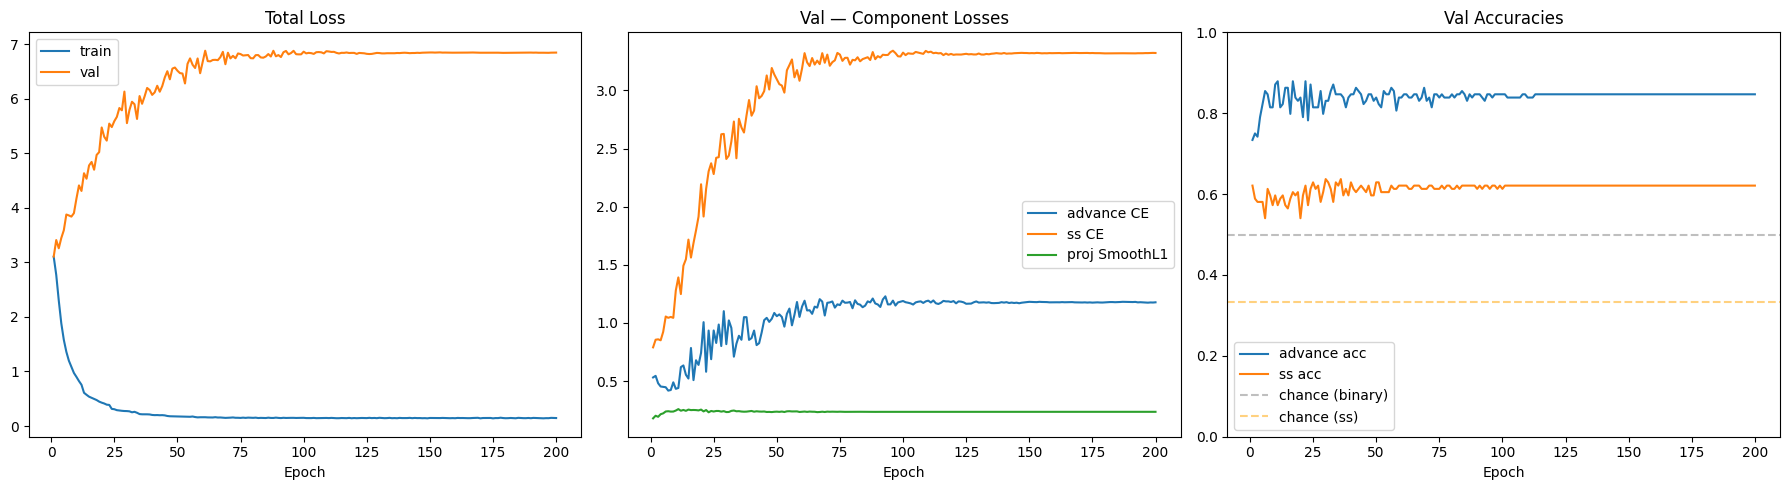

Saved: /content/drive/MyDrive/training_data/training_curves_cog_aware.png


In [143]:
E = range(1, len(log["train"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(E, log["train"], label="train")
axes[0].plot(E, log["val"],   label="val")
axes[0].set_title("Total Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(E, log["val_advance"], label="advance CE")
axes[1].plot(E, log["val_ss"],      label="ss CE")
axes[1].plot(E, log["val_proj"],    label="proj SmoothL1")
axes[1].set_title("Val — Component Losses")
axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(E, log["advance_acc"], label="advance acc")
axes[2].plot(E, log["ss_acc"],      label="ss acc")
axes[2].axhline(0.5, color="gray",   linestyle="--", alpha=0.5, label="chance (binary)")
axes[2].axhline(1/N_SUPPORT_STATES, color="orange", linestyle="--", alpha=0.5, label="chance (ss)")
axes[2].set_title("Val Accuracies"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1); axes[2].legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_data/training_curves_cog_aware.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/drive/MyDrive/training_data/training_curves_cog_aware.png")


## 13. Inference — 3-Pass Staged Sampling

**Pipeline:**
1. **Pass 1:** Encode history → predict `b`, `layer_id`, `support_state`
2. **Pass 2:** Given `(b, layer_id)`, score each history token → argmax over sup_mask → `s1`, `s2`
3. **Pass 3:** Conditioned on `s1`, `s2` → predict projection mean → add Gaussian noise from `SIGMA_PROJ_INFER`
4. Decode `(x, y, r)` from `[alpha_A, perp_A, alpha_B, perp_B]` onto support critical lines
5. Snap `z` from `z_lookup[layer_id]`
6. Assemble full 5D pose candidate `[x, y, z, b, r]`

In [144]:
def decode_pose_from_projections(support_state, s1_pose, s2_pose,
                                  alpha_A, perp_A, alpha_B, perp_B):
    """
    Recover world (x, y, r) from critical-point projections.

    s1_pose / s2_pose : [x, y, z, b, r]
    Returns [x, y, r] or None if support_state == 0.
    """
    def decode_point(sup_pose, alpha, perp):
        sA, sB, s_half = get_critical_points(sup_pose)
        span = 2.0 * s_half
        dx, dy = sB[0] - sA[0], sB[1] - sA[1]
        d  = math.sqrt(dx * dx + dy * dy + 1e-8)
        ax, ay = dx / d, dy / d
        px, py = -ay, ax
        wx = sA[0] + alpha * span * ax + perp * span * px
        wy = sA[1] + alpha * span * ay + perp * span * py
        return [wx, wy]

    if support_state == 0 or s1_pose is None:
        return None

    tA = decode_point(s1_pose, alpha_A, perp_A)
    tB = decode_point(s2_pose if (support_state == 2 and s2_pose is not None) else s1_pose,
                      alpha_B, perp_B)

    cx = (tA[0] + tB[0]) / 2.0
    cy = (tA[1] + tB[1]) / 2.0
    r  = canonicalize_r(math.atan2(tA[1] - tB[1], tA[0] - tB[0]))
    return [cx, cy, r]


In [145]:
def sample_next_brick(model, history_5d, norm_stats, z_lookup, n_candidates=100):
    """
    3-pass staged inference.

    Pass 1: predict advance -> derive next_layer, b (period-3 pattern), z (z_lookup)
    Pass 2: predict support_state from scene encoding
    Pass 3: randomly pick s1 from prev_layer; nearest-neighbour s2;
            condition proj_head on s1/s2 embeddings; sample projections.

    Returns (candidates, pred_b, pred_layer, pred_ss, pred_advance).
    """
    ns = norm_stats
    model.eval()

    layer_ids = assign_layer_ids(history_5d) if history_5d else []
    encoded = [
        encode_brick(history_5d[t], layer_ids[t], t,
                     history_5d[:t], layer_ids[:t], ns)
        for t in range(len(history_5d))
    ]

    tokens = torch.zeros(1, MAX_BRICKS, FEATURE_DIM, dtype=torch.float32)
    mask   = torch.zeros(1, MAX_BRICKS, dtype=torch.bool)
    for i, h in enumerate(encoded[:MAX_BRICKS]):
        tokens[0, i] = torch.tensor(h, dtype=torch.float32)
        mask[0, i]   = True
    tokens = tokens.to(device)
    mask   = mask.to(device)

    # ── Pass 1: predict advance -> derive layer / b / z ──────────────────────
    dummy_sup = torch.zeros(1, MAX_BRICKS, dtype=torch.bool, device=device)
    with torch.no_grad():
        advance_logits, ss_logits, _ = model(tokens, mask, dummy_sup)

    pred_advance   = int(advance_logits[0].argmax())
    max_hist_layer = max(layer_ids) if layer_ids else -1
    pred_layer     = max(0, max_hist_layer + pred_advance)
    pred_b         = b_from_layer(pred_layer)
    pred_z         = snap_z(pred_layer)
    pred_ss        = int(ss_logits[0].argmax())

    # ── Pass 2: heuristic support selection based on pred_ss ──────────────────
    prev_layer  = pred_layer - 1
    sup_indices = [i for i, lid in enumerate(layer_ids[:MAX_BRICKS]) if lid == prev_layer]

    pred_s1, pred_s2 = -1, -1
    s1_pose,  s2_pose = None, None

    if pred_ss > 0 and sup_indices:
        # Filter sup_indices to those within SUPPORT_RADIUS_M of the target brick centre
        # (approximate: use Euclidean distance from target centroid to support centroid)
        # Note: this approximation helps to prevent very distant bricks from being chosen
        # as supports, even if they're on the correct layer.
        if history_5d:
            # Calculate approximate target center based on existing bricks
            # This is a heuristic to guide support selection for the new brick
            avg_x = np.mean([p[0] for p in history_5d])
            avg_y = np.mean([p[1] for p in history_5d])
            tgt_xy_approx = [avg_x, avg_y]
        else:
            tgt_xy_approx = [0.0, 0.0] # Fallback if history is empty

        nearby = [i for i in sup_indices
                  if math.sqrt((history_5d[i][0] - tgt_xy_approx[0])**2 +
                               (history_5d[i][1] - tgt_xy_approx[1])**2) < SUPPORT_RADIUS_M * 3
                 ] or sup_indices # Fallback to all if none in radius

        if nearby:
            pred_s1 = random.choice(nearby)
            s1_pose = history_5d[pred_s1]

            if pred_ss == 2 and len(nearby) > 1:
                s1_xy  = [s1_pose[0], s1_pose[1]]
                # Find the nearest other brick in `nearby` to s1 for s2
                others = [(i, (history_5d[i][0]-s1_xy[0])**2 + (history_5d[i][1]-s1_xy[1])**2)
                          for i in nearby if i != pred_s1]
                if others:
                    pred_s2 = min(others, key=lambda x: x[1])[0]
                    s2_pose = history_5d[pred_s2]

    # ── Pass 3: predict projections conditioned on s1/s2 ─────────────────────
    sup_mask = torch.zeros(1, MAX_BRICKS, dtype=torch.bool, device=device)
    for i in sup_indices:
        sup_mask[0, i] = True

    layer_t = torch.tensor([pred_layer], dtype=torch.long, device=device)
    s1_t    = torch.tensor([pred_s1 if pred_s1 >= 0 else MAX_BRICKS], dtype=torch.long, device=device)
    s2_t    = torch.tensor([pred_s2 if pred_s2 >= 0 else MAX_BRICKS], dtype=torch.long, device=device)

    with torch.no_grad():
        _, _, proj_mean = model(tokens, mask, sup_mask,
                                cond_layer=layer_t, cond_s1=s1_t, cond_s2=s2_t)

    mu_proj = proj_mean[0].cpu().numpy()
    sigmas  = np.array(SIGMA_PROJ_INFER)

    candidates = []
    for _ in range(n_candidates):
        proj_s = mu_proj + np.random.randn(4) * sigmas
        alpha_A, perp_A, alpha_B, perp_B = proj_s.tolist()

        if pred_ss == 0 or s1_pose is None:
            # If ground support or no s1 found, sample position randomly around history mean
            lx = [h[0] for h in history_5d] or [0.0]
            ly = [h[1] for h in history_5d] or [0.0]
            x  = float(np.mean(lx)) + random.gauss(0, 0.02)
            y  = float(np.mean(ly)) + random.gauss(0, 0.02)
            r  = canonicalize_r(random.uniform(0, math.pi))
        else:
            result = decode_pose_from_projections(
                pred_ss, s1_pose, s2_pose, alpha_A, perp_A, alpha_B, perp_B,
            )
            if result is None:
                continue
            x, y, r = result

        candidates.append({
            "x": x, "y": y, "z": pred_z,
            "b": pred_b, "r": r,
            "sin_r": math.sin(r), "cos_r": math.cos(r),
            "layer_id": pred_layer,
            "support_state": pred_ss,
            "s1_idx": pred_s1, "s2_idx": pred_s2,
        })

    return candidates, pred_b, pred_layer, pred_ss, pred_advance

In [139]:
# Load the model with the best validation loss
best_model_ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(best_model_ckpt["model_state"])
print(f"Loaded best model from epoch {best_model_ckpt['epoch']}, with val_loss={best_model_ckpt['val_loss']:.4f}")

Loaded best model from epoch 1, with val_loss=3.1078


**To load the latest saved model:**

In [146]:
# Load the latest saved model
latest_model_ckpt = torch.load(LATEST_CKPT, map_location=device)
model.load_state_dict(latest_model_ckpt["model_state"])
print(f"Loaded latest model from epoch {latest_model_ckpt['epoch']}, with val_loss={latest_model_ckpt['val_loss']:.4f}")

Loaded latest model from epoch 200, with val_loss=6.8483


Demo seq: demo_7  |  history: 26 bricks


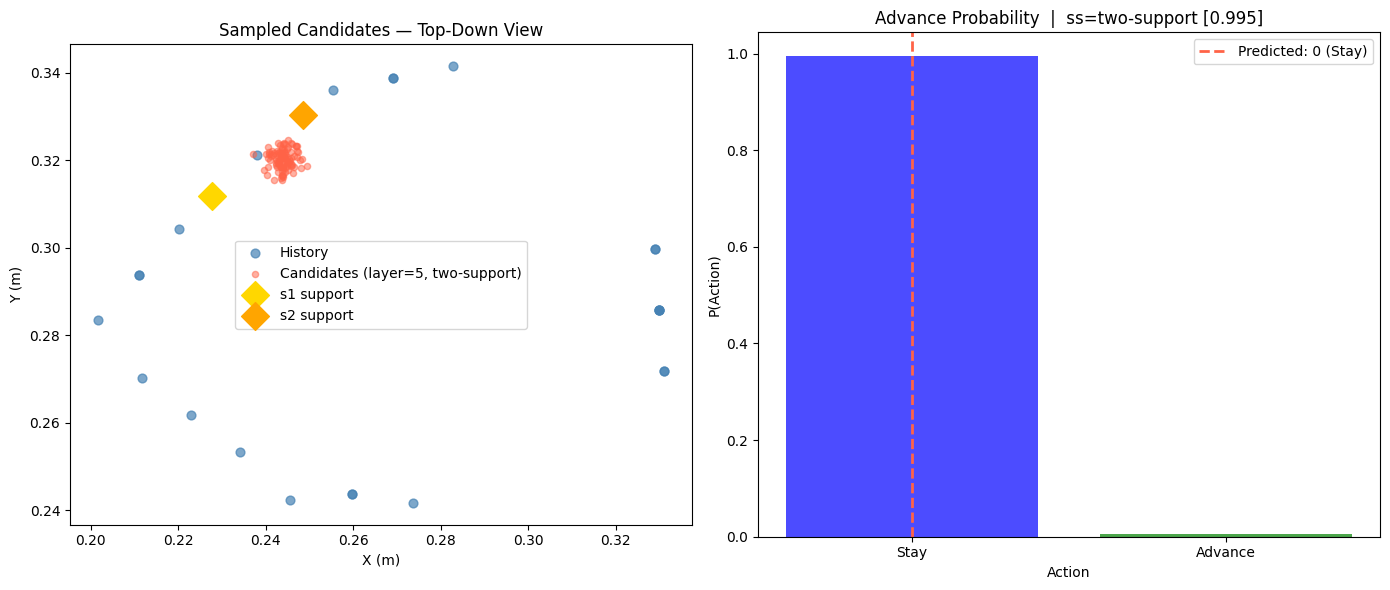

Predicted b: laying
Predicted layer=5, snapped z=0.1707m
Support state: two-support  (ground=0.000 one=0.005 two=0.995)
Generated 100 candidates


In [165]:
# Pick a val pair randomly for a meaningful demo
demo_pair = random.choice(val_pairs)
print(f"Demo seq: {Path(demo_pair['seq_id']).name}  |  "
      f"history: {len(demo_pair['history_raw'])} bricks")

history_5d = [list(h) for h in demo_pair["history_raw"]]
candidates, pred_b, pred_layer, pred_ss, pred_advance = sample_next_brick(
    model, history_5d, norm_stats, z_lookup, n_candidates=100,
)
pred_z = snap_z(pred_layer)
ss_names = {0: "ground", 1: "one-support", 2: "two-support"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
hx = [h[0] for h in history_5d]
hy = [h[1] for h in history_5d]
ax.scatter(hx, hy, c="steelblue", s=40, alpha=0.7, label="History", zorder=3)

tgt = demo_pair
tgt_pose = demo_pair["history_raw"][-1]   # last history brick as proxy for layout
ax.scatter(
    [c["x"] for c in candidates],
    [c["y"] for c in candidates],
    c="tomato", s=20, alpha=0.5,
    label=f"Candidates (layer={pred_layer}, {ss_names[pred_ss]})", zorder=4,
)
if candidates[0]["s1_idx"] >= 0:
    s1 = history_5d[candidates[0]["s1_idx"]]
    ax.scatter([s1[0]], [s1[1]], c="gold", s=200, marker="D", label="s1 support", zorder=5)
if candidates[0]["s2_idx"] >= 0:
    s2 = history_5d[candidates[0]["s2_idx"]]
    ax.scatter([s2[0]], [s2[1]], c="orange", s=200, marker="D", label="s2 support", zorder=5)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title("Sampled Candidates — Top-Down View")
ax.legend(); ax.set_aspect("equal")

# Layer probability bar chart
ax2 = axes[1]
with torch.no_grad():
    tokens = torch.zeros(1, MAX_BRICKS, FEATURE_DIM, dtype=torch.float32)
    mask_t = torch.zeros(1, MAX_BRICKS, dtype=torch.bool)
    layer_ids_d = assign_layer_ids(history_5d)
    for i, (pose, lid) in enumerate(zip(history_5d[:MAX_BRICKS], layer_ids_d[:MAX_BRICKS])):
        tokens[0, i] = torch.tensor(
            encode_brick(pose, lid, i, history_5d[:i], layer_ids_d[:i], norm_stats),
            dtype=torch.float32)
        mask_t[0, i] = True
    dummy_sup = torch.zeros(1, MAX_BRICKS, dtype=torch.bool, device=device)
    # Fix the unpacking error: model now returns 3 values
    advance_logits, ss_logits_output, _ = model(
        tokens.to(device), mask_t.to(device), dummy_sup)

    # Recalculate advance probability and adapt the b probability from pred_b
    advance_prob = F.softmax(advance_logits[0], dim=-1).cpu().numpy()

    # The b and layer_id are now deterministically derived from advance_logits
    # and `pred_layer` / `pred_b` from `sample_next_brick` function output
    # For the bar chart, we'll plot the advance probability instead of layer_prob

    ss_prob    = F.softmax(ss_logits_output[0],    dim=-1).cpu().numpy()

ax2.bar([0, 1], advance_prob, color=["blue", "green"], alpha=0.7, tick_label=["Stay", "Advance"])
ax2.axvline(pred_advance, color="tomato", linewidth=2, linestyle="--",
            label=f"Predicted: {pred_advance} ({'Stay' if pred_advance == 0 else 'Advance'})")
ax2.set_xlabel("Action"); ax2.set_ylabel("P(Action)")
ax2.set_title(f"Advance Probability  |  ss={ss_names[pred_ss]} [{ss_prob[pred_ss]:.3f}]")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_data/candidate_visualization_cog_aware.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Predicted b: {'laying' if pred_b == 0 else 'standing'}")
print(f"Predicted layer={pred_layer}, snapped z={pred_z:.4f}m")
print(f"Support state: {ss_names[pred_ss]}  "
      f"(ground={ss_prob[0]:.3f} one={ss_prob[1]:.3f} two={ss_prob[2]:.3f})")
print(f"Generated {len(candidates)} candidates")